# Lab 7: Kalman Filter

## 1. Step Response — Estimate Drag and Momentum

In [489]:
import numpy as np
import matplotlib.pyplot as plt


### Collect step response data from robot

Connect to the robot, run PID with a constant PWM step input, and retrieve the logged ToF + motor data.

In [490]:
import asyncio
import sys
sys.path.insert(0, ".")
from main_python.ble.connection import BLEConnection
from main_python.commands.step import StepResponse, SendStepData


In [491]:
# Collect step response: drive forward at constant PWM and log ToF data
# Adjust STEP_PWM and DURATION_MS for your robot
STEP_PWM = 196  # PWM step input (out of 255)
DURATION_MS = 5000

async def collect_step_response():
    async with BLEConnection() as robot:
        await robot.execute(StepResponse(duration_ms=DURATION_MS, pwm=STEP_PWM))
        await asyncio.sleep(DURATION_MS / 1000 + 0.5)
        step_data = await robot.execute(SendStepData())
        return step_data

# step_data = await collect_step_response()
# Uncomment above when connected to robot


### Load saved data

Load from a saved CSV/pickle, or populate arrays manually from robot data.

In [ ]:
# Motor low-pass filter parameters (must match firmware)
MOTOR_RC = 0.02  # seconds (motors::motor_rc)

def lpf_alpha(dt, rc):
    """Low-pass filter alpha matching firmware: 1 - exp(-dt/rc)."""
    return 1 - np.exp(-dt / rc)

# Option A: Load from step response data collected above
# t0 = step_data[0].time
# times = np.array([(s.time - t0) / 1e6 for s in step_data])  # us -> s
# tof = np.array([s.dist for s in step_data])                  # mm
# pwm_raw = np.array([s.motor for s in step_data])             # PWM target

# Option B: Load from saved file
import pickle
with open("step_response.pkl", "rb") as f:
    saved = pickle.load(f)
    times, tof, pwm_raw = saved["times"], saved["tof"], saved["pwm"]

# Apply the same low-pass filter as firmware motors subsystem.
# The logged PWM is the target; the actual motor output is LPF'd.
pwm = np.zeros_like(pwm_raw, dtype=float)
u_filt = 0.0
for i in range(len(times)):
    dt_i = times[i] - times[i - 1] if i > 0 else 0.01
    alpha = lpf_alpha(dt_i, MOTOR_RC)
    u_filt += alpha * (pwm_raw[i] - u_filt)
    pwm[i] = u_filt

print(f"Loaded {len(times)} samples, LPF applied (RC={MOTOR_RC}s)")


Loaded 26 samples, LPF applied (RC=0.02s)


### Plot ToF distance, velocity, and motor input

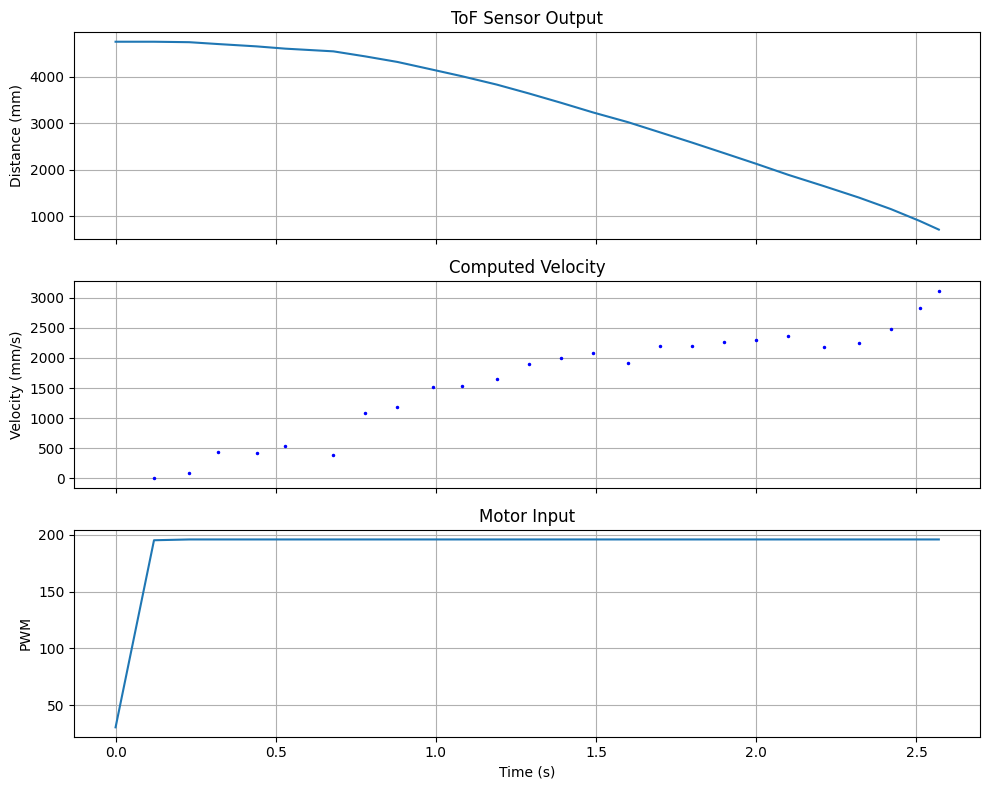

In [493]:
# Compute velocity from ToF distance (negative because distance decreases)
dt = np.diff(times)
velocity = -np.diff(tof) / dt  # mm/s

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(times, tof)
axes[0].set_ylabel("Distance (mm)")
axes[0].set_title("ToF Sensor Output")
axes[0].grid(True)

axes[1].plot(times[1:], velocity, "b.", markersize=3)
axes[1].set_ylabel("Velocity (mm/s)")
axes[1].set_title("Computed Velocity")
axes[1].grid(True)

axes[2].plot(times, pwm)
axes[2].set_ylabel("PWM")
axes[2].set_title("Motor Input")
axes[2].set_xlabel("Time (s)")
axes[2].grid(True)

plt.tight_layout()
plt.savefig("../images/step_response.png", dpi=150, bbox_inches="tight")
plt.show()


### Compute drag and momentum via state-space simulation fit

Instead of fitting the analytical step response (which assumes constant PWM and
uniform timesteps), we simulate the discrete state-space model forward using
the actual PWM inputs and variable dt from the data. This produces `d` and `m`
values that reflect the real dynamics including variable sampling and any
non-constant inputs.

Drag (d):     0.8095 1/s  (time constant: 1.24 s)
Momentum (m): 11.8318 mm/s² per PWM
Steady state: 2865 mm/s at PWM=196
ToF interval: 103 ms avg


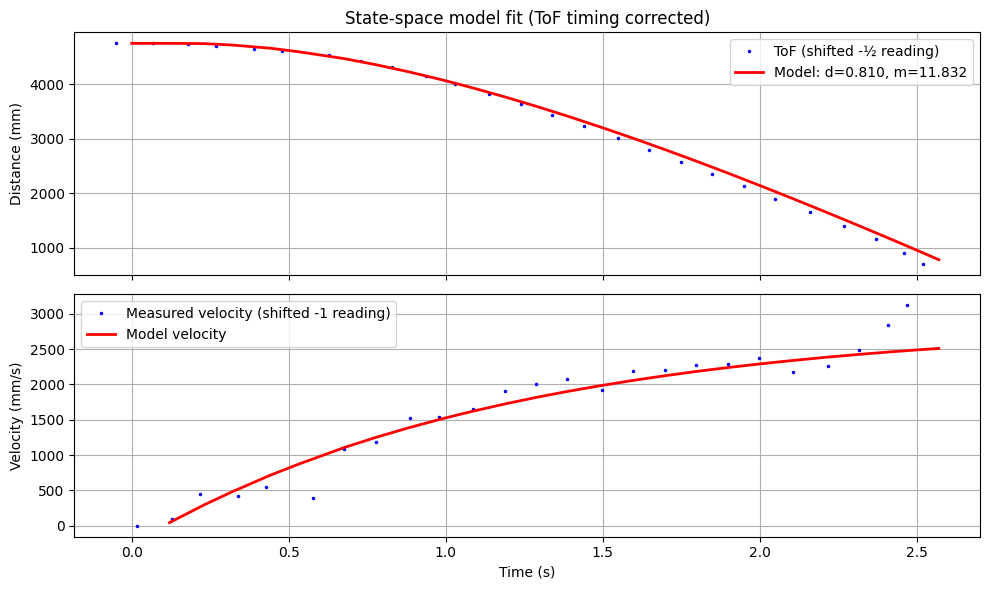

In [494]:
from scipy.optimize import minimize

# Steady-state speed constraint (soft)
V_SS_MIN = 2250.0  # mm/s — lower bound
V_SS_MAX = 2750.0  # mm/s — upper bound
V_SS_WEIGHT = 0.5  # penalty weight relative to position MSE

def simulate(params, times, pwm, tof_0):
    """Simulate discrete state-space model with variable dt.

    PWM is already low-pass filtered to match firmware motor output.
    Returns positions and velocities at each timestep.
    """
    d_val, m_val = params
    pos = tof_0
    vel = 0.0
    positions = [pos]
    velocities = [vel]

    for i in range(1, len(times)):
        dt_i = times[i] - times[i - 1]
        vel_new = vel + dt_i * (-d_val * vel - m_val * pwm[i - 1])
        pos_new = pos + dt_i * vel
        pos = pos_new
        vel = vel_new
        positions.append(pos)
        velocities.append(vel)

    return np.array(positions), np.array(velocities)

# ToF timing correction
half_dt = np.mean(np.diff(times)) / 2
full_dt = np.mean(np.diff(times))
times_pos_corrected = times - half_dt
times_vel_corrected = times - full_dt

def fit_cost(log_params):
    """Fit d and m with soft steady-state speed constraint."""
    d_val, m_val = np.exp(log_params)
    pred_pos, _ = simulate((d_val, m_val), times, pwm, tof[0])
    pos_err = np.sum((pred_pos - tof)**2)

    # Soft penalty: penalize if v_ss falls outside [V_SS_MIN, V_SS_MAX]
    v_ss = m_val * STEP_PWM / d_val
    if v_ss < V_SS_MIN:
        ss_penalty = (V_SS_MIN - v_ss)**2
    elif v_ss > V_SS_MAX:
        ss_penalty = (v_ss - V_SS_MAX)**2
    else:
        ss_penalty = 0.0

    return pos_err + V_SS_WEIGHT * ss_penalty

x0 = np.log([0.5, 5.0])
result = minimize(fit_cost, x0, method="Nelder-Mead")
d, m = np.exp(result.x)

pred_pos, pred_vel = simulate((d, m), times, pwm, tof[0])

print(f"Drag (d):     {d:.4f} 1/s  (time constant: {1/d:.2f} s)")
print(f"Momentum (m): {m:.4f} mm/s² per PWM")
print(f"Steady state: {m * STEP_PWM / d:.0f} mm/s at PWM={STEP_PWM}")
print(f"ToF interval: {np.mean(np.diff(times))*1000:.0f} ms avg")

# Plot fit with time-corrected ToF
vel_raw = -np.diff(tof) / np.diff(times)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(times_pos_corrected, tof, "b.", markersize=3, label="ToF (shifted -½ reading)")
axes[0].plot(times, pred_pos, "r-", linewidth=2, label=f"Model: d={d:.3f}, m={m:.3f}")
axes[0].set_ylabel("Distance (mm)")
axes[0].set_title("State-space model fit (ToF timing corrected)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(times_vel_corrected[1:], vel_raw, "b.", markersize=3, label="Measured velocity (shifted -1 reading)")
axes[1].plot(times[1:], -pred_vel[1:], "r-", linewidth=2, label="Model velocity")
axes[1].set_ylabel("Velocity (mm/s)")
axes[1].set_xlabel("Time (s)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("../images/step_response_fit.png", dpi=150, bbox_inches="tight")
plt.show()


## 2. Initialize Kalman Filter

Set up A, B, C matrices and covariance matrices.

In [495]:
# State space model in distance-to-wall coordinates:
#   x = [distance, velocity]^T
#   vel_dot = -d*vel - m*u  (positive PWM decreases distance)
#   A = [[0, 1], [0, -d]]
#   B = [[0], [-m]]
#   C = [[1, 0]]
# Note: d and m may be updated by the joint NLL fit below.

A = np.array([[0, 1],
              [0, -d]])
B = np.array([[0],
              [-m]])
C = np.array([[1, 0]])

print("A =", A)
print("B =", B)
print("C =", C)


A = [[ 0.          1.        ]
 [ 0.         -0.80952062]]
B = [[  0.        ]
 [-11.83180802]]
C = [[1 0]]


In [ ]:
# Discretize at 100Hz (matches firmware timer::PERIOD_S)
DT = 0.01  # 100Hz loop period
n = 2

Ad = np.eye(n) + DT * A
Bd = DT * B

print(f"DT = {DT} s (100Hz)")
print("Ad =", Ad)
print("Bd =", Bd)

# Build 100Hz timeline and map ToF readings to nearest tick
t_end = times[-1]
t_100hz = np.arange(0, t_end + DT, DT)

# For each 100Hz tick, hold the last known (already filtered) PWM value
pwm_100hz = np.zeros(len(t_100hz))
tof_idx = 0
for k in range(len(t_100hz)):
    while tof_idx < len(times) - 1 and times[tof_idx + 1] <= t_100hz[k]:
        tof_idx += 1
    pwm_100hz[k] = pwm[tof_idx]

# Map each ToF reading to its nearest 100Hz tick index
tof_tick_indices = np.searchsorted(t_100hz, times, side="left")
tof_tick_indices = np.clip(tof_tick_indices, 0, len(t_100hz) - 1)
# Build a dict: tick_index -> tof measurement
tof_at_tick = {}
for i, tick in enumerate(tof_tick_indices):
    tof_at_tick[tick] = tof[i]

print(f"\n{len(t_100hz)} ticks at 100Hz, {len(tof)} ToF readings")


DT = 0.01 s (100Hz)
Ad = [[1.         0.01      ]
 [0.         0.99190479]]
Bd = [[ 0.        ]
 [-0.11831808]]

258 ticks at 100Hz, 26 ToF readings


In [502]:
# Hand-tunable noise covariances
# Adjust these to control how much the KF trusts model vs measurements.
# Higher sigma_vel -> trust model less (more responsive to ToF)
# Higher sigma_tof -> trust measurements less (smoother output)
sigma_1 = 1.0     # process noise: position (mm)
sigma_2 = 100.0   # process noise: velocity (mm/s)
sigma_3 = 50.0    # measurement noise: ToF (mm)

Sigma_u = np.array([[sigma_1**2, 0],
                    [0, sigma_2**2]])
Sigma_z = np.array([[sigma_3**2]])

print(f"sigma_pos: {sigma_1} mm")
print(f"sigma_vel: {sigma_2} mm/s")
print(f"sigma_tof: {sigma_3} mm")
print(f"\nSigma_u =\n{Sigma_u}")
print(f"Sigma_z =\n{Sigma_z}")


sigma_pos: 1.0 mm
sigma_vel: 100.0 mm/s
sigma_tof: 50.0 mm

Sigma_u =
[[1.e+00 0.e+00]
 [0.e+00 1.e+04]]
Sigma_z =
[[2500.]]


## 3. Implement and Test Kalman Filter

In [503]:
def kf_predict(mu, sigma, u):
    """KF predict step — runs every 10ms tick."""
    mu_p = Ad @ mu + Bd @ u
    sigma_p = Ad @ sigma @ Ad.T + Sigma_u
    return mu_p, sigma_p

def kf_update(mu, sigma, y):
    """KF update step — runs only when a new ToF reading arrives."""
    innov = y - C @ mu
    S = C @ sigma @ C.T + Sigma_z
    K = sigma @ C.T @ np.linalg.inv(S)
    mu = mu + K @ innov
    sigma = (np.eye(2) - K @ C) @ sigma
    return mu, sigma


In [504]:
# Recompute Ad/Bd from jointly fitted d, m
A = np.array([[0, 1], [0, -d]])
B = np.array([[0], [-m]])
Ad = np.eye(2) + DT * A
Bd = DT * B

print(f"Using jointly fitted: d={d:.4f}, m={m:.4f}")
print("Ad =", Ad)
print("Bd =", Bd)

# Run KF at 100Hz: predict every tick, update only on ToF readings
mu = np.array([[tof[0]], [0]])
sigma = np.eye(2) * 100

kf_positions = np.zeros(len(t_100hz))
kf_velocities = np.zeros(len(t_100hz))

for k in range(len(t_100hz)):
    u = np.array([[pwm_100hz[k]]])
    mu, sigma = kf_predict(mu, sigma, u)

    if k in tof_at_tick:
        y = np.array([[tof_at_tick[k]]])
        mu, sigma = kf_update(mu, sigma, y)

    kf_positions[k] = mu[0, 0]
    kf_velocities[k] = mu[1, 0]


Using jointly fitted: d=0.8095, m=11.8318
Ad = [[1.         0.01      ]
 [0.         0.99190479]]
Bd = [[ 0.        ]
 [-0.11831808]]


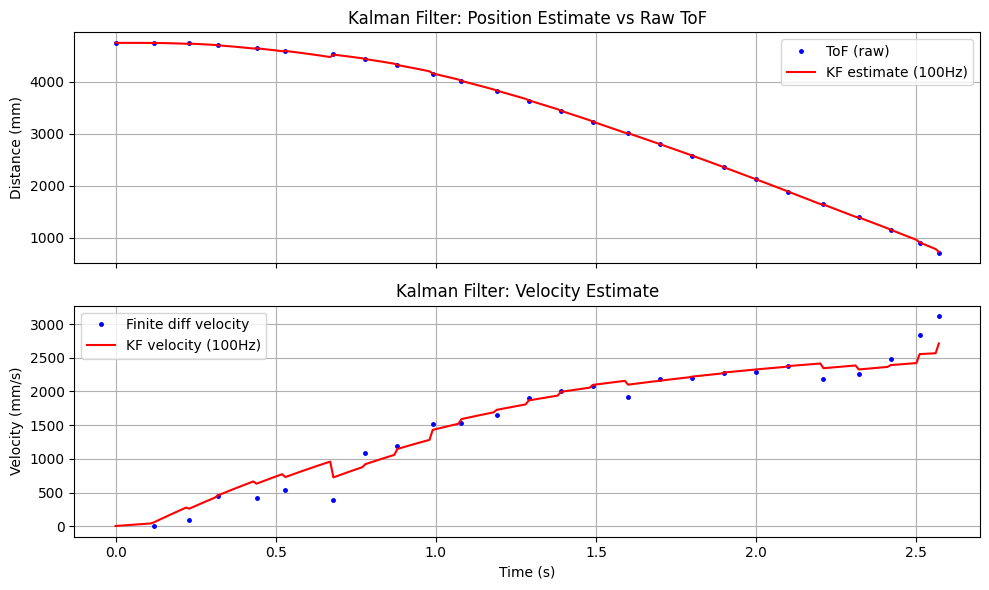

In [505]:
# Plot KF estimate vs raw ToF
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(times, tof, "b.", markersize=5, label="ToF (raw)")
axes[0].plot(t_100hz, kf_positions, "r-", linewidth=1.5, label="KF estimate (100Hz)")
axes[0].set_ylabel("Distance (mm)")
axes[0].set_title("Kalman Filter: Position Estimate vs Raw ToF")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(times[1:], velocity, "b.", markersize=5, label="Finite diff velocity")
axes[1].plot(t_100hz, -kf_velocities, "r-", linewidth=1.5, label="KF velocity (100Hz)")
axes[1].set_ylabel("Velocity (mm/s)")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("Kalman Filter: Velocity Estimate")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("../images/kalman_filter.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Save data for reuse

In [506]:
import pickle

data_to_save = {
    "times": times,
    "tof": tof,
    "pwm": pwm,
    "kf_positions": kf_positions,
    "kf_velocities": kf_velocities,
    "d": d,
    "m": m,
    "sigma_1": sigma_1,
    "sigma_2": sigma_2,
    "sigma_3": sigma_3,
}

with open("step_response.pkl", "wb") as f:
    pickle.dump(data_to_save, f)
print("Saved to step_response.pkl")


Saved to step_response.pkl
